<table align="center">
  <td align="center"><a target="_blank" href="http://introtodeeplearning.com">
        <img src="https://i.ibb.co/Jr88sn2/mit.png" style="padding-bottom:5px;" />
      Visit MIT Deep Learning</a></td>
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/MITDeepLearning/introtodeeplearning/blob/master/lab2/PT_Part2_Debiasing.ipynb">
        <img src="https://i.ibb.co/2P3SLwK/colab.png"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
  <td align="center"><a target="_blank" href="https://github.com/MITDeepLearning/introtodeeplearning/blob/master/lab2/PT_Part2_Debiasing.ipynb">
        <img src="https://i.ibb.co/xfJbPmL/github.png"  height="70px" style="padding-bottom:5px;"  />View Source on GitHub</a></td>
</table>

# Copyright Information

In [1]:
# Copyright 2026 MIT 6.S191 Introduction to Deep Learning. All Rights Reserved.
#
# Licensed under the MIT License. You may not use this file except in compliance
# with the License. Use and/or modification of this code outside of 6.S191 must
# reference:
#
# © MIT 6.S191: Introduction to Deep Learning
# http://introtodeeplearning.com
#

# Mitigating Bias in Facial Recognition Systems

## DB-VAE Replication on UTKFace and Tiny ImageNet

This project evaluates whether a corrected Debiasing Variational Autoencoder (DB-VAE) can reduce demographic bias in facial detection when trained on more diverse and unbalanced data.

We train on UTKFace face images paired with Tiny ImageNet non-face images, then compare DB-VAE against a standard CNN classifier across 10 demographic groups (5 race labels x 2 genders).

The study also sweeps the DB-VAE alpha hyperparameter to test how sampling strength affects accuracy and debiasing performance.

**Research Questions**

- How does DB-VAE accuracy compare with a standard CNN classifier on the held-out demographic test split?
- Which alpha value gives the best tradeoff between fairness and accuracy?
- Is there a stable alpha range that consistently improves performance on imbalanced face datasets?

**Workflow**

- Train and evaluate the models in Google Colab using PyTorch.
- Compare aggregate accuracy and per-group performance to measure bias reduction.

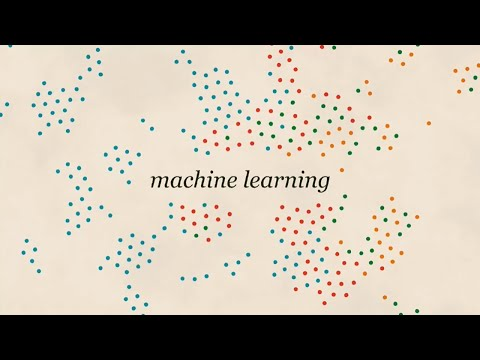

In [2]:
import IPython

IPython.display.YouTubeVideo("59bMh59JQDo")

Let's get started by installing the relevant dependencies.

We will be using Comet ML to track our model development and training runs.

1. Sign up for a Comet account: [HERE](https://www.comet.com/signup?utm_source=mit_dl&utm_medium=partner&utm_content=github)
2. This will generate a personal API Key, which you can find either in the first 'Get Started with Comet' page, under your account settings, or by pressing the '?' in the top right corner and then 'Quickstart Guide'. Enter this API key as the global variable `COMET_API_KEY` below.



In [3]:
## Comet ML (optional experiment tracking)
!pip install comet_ml --quiet
import comet_ml


# Secure API key loading
import os
from getpass import getpass

try:
    # Try Colab secrets first
    from google.colab import userdata
    COMET_API_KEY = userdata.get("COMET_API_KEY")
except:
    # Fall back to environment variable or prompt
    COMET_API_KEY = os.getenv("COMET_API_KEY")
    if not COMET_API_KEY:
        COMET_API_KEY = getpass("Enter your Comet API key (leave blank to skip): ")
assert COMET_API_KEY != "", "Please insert your Comet API Key"

# Local pipeline replacing the mitdeeplearning package.
# Datasets: UTKFace (faces) + Tiny ImageNet (non-faces), fetched via kagglehub.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from src.dataset import prepare_datasets
from src.util import LossHistory, PeriodicPlotter, plot_sample


c:\Users\Savag\anaconda3\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os
import random
import IPython
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn


# GPU is strongly preferred for DB-VAE training; CPU will be very slow.
if torch.cuda.is_available():
    device = torch.device("cuda")
    cudnn.benchmark = True
    print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("WARNING: no CUDA device; falling back to CPU. Training will be slow.")


Using CUDA device: NVIDIA GeForce RTX 3060 Laptop GPU


## 2.1 Datasets

We use two locally-cached datasets (no Dropbox download):

1. **Positive training data (faces)**: [UTKFace](https://susanqq.github.io/UTKFace/) — ~24k aligned 200x200 face crops with filenames `{age}_{gender}_{race}_{ts}.jpg`. Resized to 64x64 by the local loader.
2. **Negative training data (non-faces)**: [Tiny ImageNet](https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet) — 200 classes of generic objects/animals/scenes, already 64x64. We sample 125 images per class (~25k total) to roughly balance the face pool.
3. **Demographic test split**: held out from UTKFace before training. Each of the 5 UTKFace race labels (White, Black, Asian, Indian, Other) × 2 genders gives **10 groups of 200 faces each**. This lets us examine per-race × per-gender classification behavior separately rather than collapsing into coarse Light/Dark skin-tone proxies.

Both datasets are downloaded and decoded once into `./data/` and `./data/cache/`. The cell below builds the cache on first run (a few minutes) and loads instantly on subsequent runs.


In [5]:
### Build/load the local datasets ###
# First run downloads UTKFace (~330MB) and Tiny ImageNet (~474MB) via kagglehub,
# then decodes both into ./data/cache/*.npy. Re-runs are instant.

loader, test_faces, keys = prepare_datasets()
print(f"Train pool: {loader.get_train_size()} examples "
      f"(faces={loader.n_faces}, nonfaces={loader.n_nonfaces})")
print(f"Test groups: {keys}; {test_faces[0].shape[0]} faces per group")
channels_last = False  # kept for API compatibility with downstream cells


Train pool: 46705 examples (faces=21705, nonfaces=25000)
Test groups: ['White Female', 'White Male', 'Black Female', 'Black Male', 'Asian Female', 'Asian Male', 'Indian Female', 'Indian Male', 'Other Female', 'Other Male']; 200 faces per group


We can look at the size of the training dataset and grab a batch of size 100:

In [6]:
number_of_training_examples = loader.get_train_size()
(images, labels) = loader.get_batch(100)

In [7]:
B, C, H, W = images.shape

Play around with displaying images to get a sense of what the training data actually looks like!

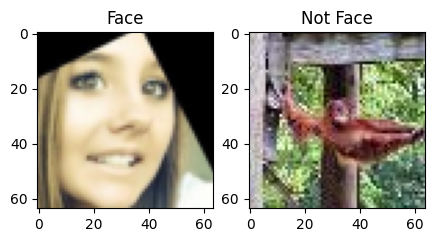

In [8]:
### Examining the CelebA training dataset ###

# @title Change the sliders to look at positive and negative training examples! { run: "auto" }

face_images = images[np.where(labels == 1)[0]].transpose(0, 2, 3, 1)
not_face_images = images[np.where(labels == 0)[0]].transpose(0, 2, 3, 1)

idx_face = 21  # @param {type:"slider", min:0, max:50, step:1}
idx_not_face = 17  # @param {type:"slider", min:0, max:50, step:1}

plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face")
plt.grid(False)

### Thinking about bias

Remember we'll be training our facial detection classifiers on the large, well-curated CelebA dataset (and ImageNet), and then evaluating their accuracy by testing them on an independent test dataset. Our goal is to build a model that trains on CelebA *and* achieves high classification accuracy on the the test dataset across all demographics, and to thus show that this model does not suffer from any hidden bias.

What exactly do we mean when we say a classifier is biased? In order to formalize this, we'll need to think about [*latent variables*](https://en.wikipedia.org/wiki/Latent_variable), variables that define a dataset but are not strictly observed. As defined in the generative modeling lecture, we'll use the term *latent space* to refer to the probability distributions of the aforementioned latent variables. Putting these ideas together, we consider a classifier *biased* if its classification decision changes after it sees some additional latent features. This notion of bias may be helpful to keep in mind throughout the rest of the lab.

**#Review** understanding of Latent Variables if needed ↑

## 2.2 CNN for facial detection

First, we'll define and train a CNN on the facial classification task, and evaluate its accuracy. Later, we'll evaluate the performance of our debiased models against this baseline CNN. The CNN model has a relatively standard architecture consisting of a series of convolutional layers with batch normalization followed by two fully connected layers to flatten the convolution output and generate a class prediction.

### Define and train the CNN model

Like we did in the first part of the lab, we'll define our CNN model, and then train on the CelebA and ImageNet datasets by leveraging PyTorch's automatic differentiation (`torch.autograd`) by using the `loss.backward()` and `optimizer.step()` functions.

In [9]:
### Define the CNN model ###

n_filters = 12  # base number of convolutional filters
in_channels = images.shape[1]

def make_standard_classifier(n_outputs):
  """Create a standard CNN classifier."""

  # Start by first defining a convolutional block
  class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.relu = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        return x

  # now use the block to define the classifier
  model = nn.Sequential(
      ConvBlock(in_channels, n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(n_filters, 2*n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(2*n_filters, 4*n_filters, kernel_size=3, stride=2, padding=1),
      ConvBlock(4*n_filters, 6*n_filters, kernel_size=3, stride=2, padding=1),
      nn.Flatten(),
      nn.Linear(H // 16 * W // 16 * 6 * n_filters, 512),
      nn.ReLU(inplace=True),
      nn.Linear(512, n_outputs),
  )

  return model.to(device)

# call the function to instantiate a classifier model
standard_classifier = make_standard_classifier(n_outputs=1)
print(standard_classifier)

Sequential(
  (0): ConvBlock(
    (conv): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): ConvBlock(
    (conv): Conv2d(12, 24, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (2): ConvBlock(
    (conv): Conv2d(24, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): ConvBlock(
    (conv): Conv2d(48, 72, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=1152, out_features=512, bias=True)
  (6

Now let's train the standard CNN!

*Got confused here*

In [10]:
### Create a Comet experiment to track our training run ###
def create_experiment(project_name, params):
    # end any prior experiments
    if "experiment" in locals():
        experiment.end()

    # initiate the comet experiment for tracking
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name=project_name)
    # log our hyperparameters, defined above, to the experiment
    for param, value in params.items():
        experiment.log_parameter(param, value)
    experiment.flush()

    return experiment


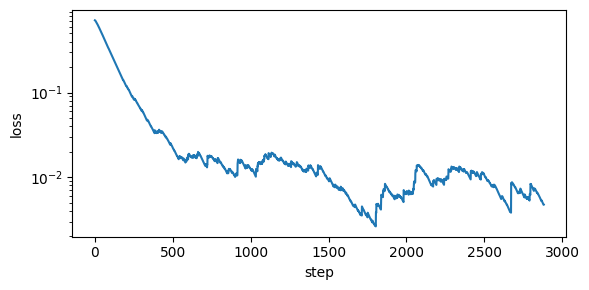

100%|██████████| 1459/1459 [00:14<00:00, 97.62it/s] 
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : inner_rosin_151
COMET INFO:     url                   : https://www.comet.com/kwadwot/6s191-lab2-part2-cnn/72385a01f6e443179af142b855f849d0
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [3210] : (3.445308891514287e-07, 0.7126857042312622)
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 32
COMET INFO:     learning_rate : 0.0005
COMET INFO:     num_epochs    : 2
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     source_code     

In [11]:
### Train the standard CNN ###
loss_fn = nn.BCEWithLogitsLoss()
# Training hyperparameters
params = dict(
    batch_size=32,
    num_epochs=2,  # keep small to run faster
    learning_rate=5e-4,
)

experiment = create_experiment("6S191_Lab2_Part2_CNN", params)

optimizer = optim.Adam(
    standard_classifier.parameters(), lr=params["learning_rate"]
)  # define our optimizer
loss_history = LossHistory(smoothing_factor=0.99)  # to record loss evolution
plotter = PeriodicPlotter(sec=2, scale="semilogy")
if hasattr(tqdm, "_instances"):
    tqdm._instances.clear()  # clear if it exists

# set the model to train mode
standard_classifier.train()


def standard_train_step(x, y):
    x = torch.from_numpy(x).float().to(device)
    y = torch.from_numpy(y).float().to(device)

    # clear the gradients
    optimizer.zero_grad()

    # feed the images into the model
    logits = standard_classifier(x)
    # Compute the loss
    loss = loss_fn(logits, y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss


# The training loop!
step = 0
for epoch in range(params["num_epochs"]):
    for idx in tqdm(range(loader.get_train_size() // params["batch_size"])):
        # Grab a batch of training data and propagate through the network
        x, y = loader.get_batch(params["batch_size"])
        loss = standard_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()

        # Record the loss and plot the evolution of the loss as a function of training
        loss_history.append(loss_value)
        plotter.plot(loss_history.get())

        experiment.log_metric("loss", loss_value, step=step)
        step += 1

experiment.end()

### Evaluate performance of the standard CNN

Next, let's evaluate the classification performance of our CelebA-trained standard CNN on the training dataset.


In [12]:
### Evaluation of standard CNN ###

# set the model to eval mode
standard_classifier.eval()

# TRAINING DATA
# Evaluate on a subset of CelebA+Imagenet
(batch_x, batch_y) = loader.get_batch(5000)
batch_x = torch.from_numpy(batch_x).float().to(device)
batch_y = torch.from_numpy(batch_y).float().to(device)

with torch.inference_mode():
    y_pred_logits = standard_classifier(batch_x)
    y_pred_standard = torch.round(torch.sigmoid(y_pred_logits))
    acc_standard = torch.mean((batch_y == y_pred_standard).float())

print(
    "Standard CNN accuracy on (potentially biased) training set: {:.4f}".format(
        acc_standard.item()
    )
)

Standard CNN accuracy on (potentially biased) training set: 0.9978


We will also evaluate our networks on an independent test set of UTKFace images that were held out from training. For the test data, we'll look at the classification rate across **10 demographic groups** — each of the 5 UTKFace race labels (White, Black, Asian, Indian, Other) × 2 genders. This gives a finer-grained view of race-and-gender classification behavior than the original Light/Dark skin-tone proxy split.

Let's take a look at some sample faces in the test set.

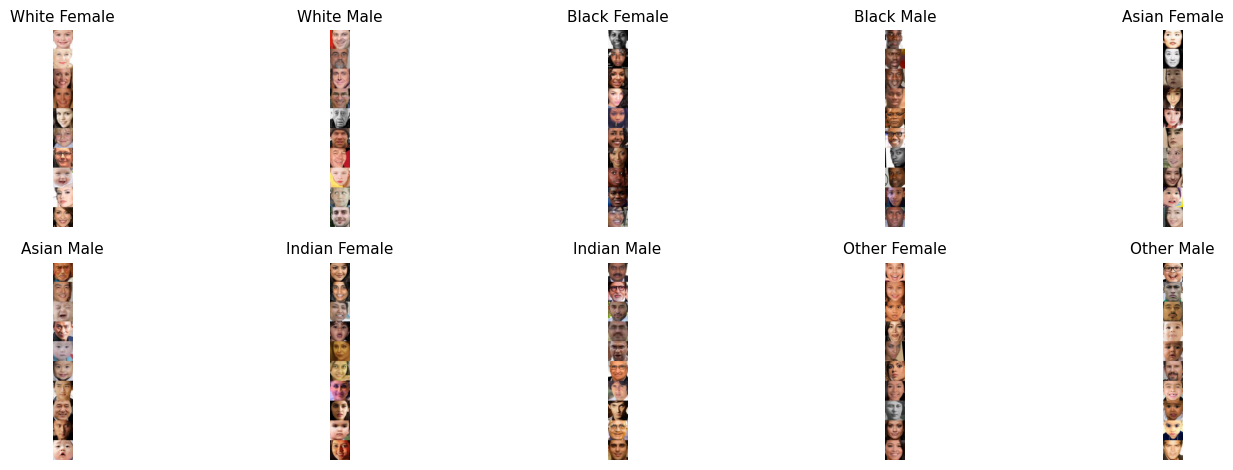

In [13]:
### test_faces and keys were already loaded by prepare_datasets() above ###
# Plot sample faces per demographic group — 2x5 grid, 10 faces hstacked per panel.

n_show = 10
n_cols = 5
n_rows = (len(keys) + n_cols - 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.4 * n_rows))
axs = np.atleast_2d(axs)
for i, (group, key) in enumerate(zip(test_faces, keys)):
    row, col = divmod(i, n_cols)
    axs[row, col].imshow(np.hstack(group[:n_show]).transpose(1, 2, 0))
    axs[row, col].set_title(key, fontsize=11)
    axs[row, col].axis("off")
# hide any unused panels
for i in range(len(keys), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axs[row, col].axis("off")
plt.tight_layout()


Now, let's evaluate the probability of each of these face demographics being classified as a face using the standard CNN classifier we've just trained.

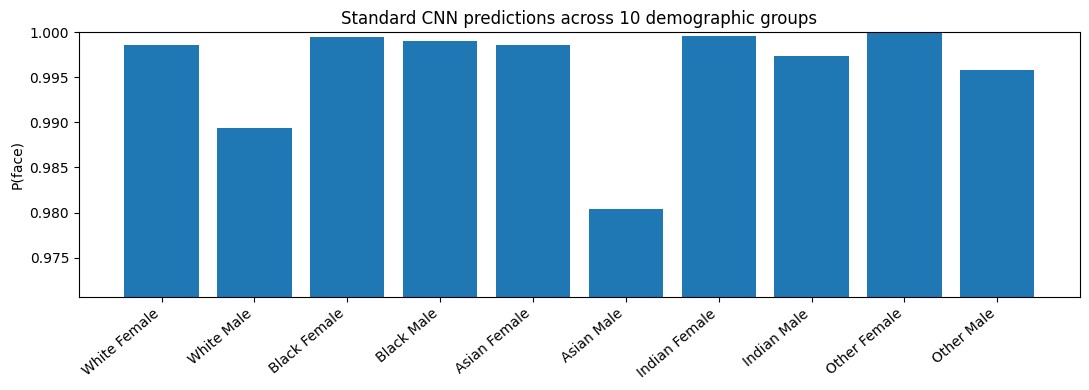

In [14]:
### Evaluate the standard CNN on the test data ###

standard_classifier_probs_list = []  # store each demographic's probabilities

with torch.inference_mode():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = standard_classifier(x)  # [B, 1]
        probs = torch.sigmoid(logits)  # [B, 1]
        probs = torch.squeeze(probs, dim=-1)  # shape [B]
        standard_classifier_probs_list.append(probs.cpu().numpy())

standard_classifier_probs = np.stack(standard_classifier_probs_list, axis=0)


# Plot the prediction accuracies per demographic
xx = np.arange(len(keys))
yy = standard_classifier_probs.mean(axis=1)  # shape [D]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(xx, yy)
ax.set_xticks(xx)
ax.set_xticklabels(keys, rotation=40, ha="right")
ax.set_ylim(max(0, yy.min() - np.ptp(yy) / 2.0), min(1, yy.max() + np.ptp(yy) / 2.0))
ax.set_ylabel("P(face)")
ax.set_title("Standard CNN predictions across 10 demographic groups")
plt.tight_layout()


Take a look at the predictions for this first model across the 10 race × gender groups. What patterns do you observe — does the model treat all races and genders alike, or are some groups under- or over-confident? What are some reasons why a trained model might have biased predictions across some demographic groups?

## 2.3 Mitigating algorithmic bias

Imbalances in the training data can result in unwanted algorithmic bias. In UTKFace, for instance, White faces alone are nearly twice as common as any other race, and the Other category is smaller still — so a model trained naively on this data may be much better at recognizing faces from over-represented groups than from under-represented ones.

How could we overcome this? A naive solution -- and one that is being adopted by many companies and organizations -- would be to annotate different subclasses (e.g., particular race × gender combinations, hats, glasses, etc.) within the training data, and then manually even out the data with respect to these groups.

But this approach has two major disadvantages. First, it requires annotating massive amounts of data, which is not scalable. Second, it requires that we know what potential biases (race, gender, pose, occlusion, hats, glasses, etc.) to look for in the data. As a result, manual annotation may not capture all the different features that are imbalanced within the training data.

Instead, let's actually **learn** these features in an unbiased, unsupervised manner, without the need for any annotation, and then train a classifier fairly with respect to these features. In the rest of this lab, we'll do exactly that.

## 2.4 Variational autoencoder (VAE) for learning latent structure

As you saw, the accuracy of the CNN varies across the 10 race × gender groups we evaluated. To think about why this may be, consider the dataset the model was trained on (UTKFace). If certain features — particular skin tones, hair styles, hats, lighting conditions — are *rare* in the training data, the model may end up biased against these as a result of training with an imbalanced dataset. Its classification accuracy will be worse on faces that have under-represented features relative to faces with features well-represented in the training data. This is a problem.

Our goal is to train a *debiased* version of this classifier -- one that accounts for potential disparities in feature representation within the training data. Specifically, to build a debiased facial classifier, we'll train a model that **learns a representation of the underlying latent space** of the face training data. The model then uses this information to mitigate unwanted biases by sampling faces with rare features *more frequently* during training. The key design requirement for our model is that it can learn an *encoding* of the latent features in the face data in an entirely *unsupervised* way. To achieve this, we'll turn to variational autoencoders (VAEs).

![The concept of a VAE](https://i.ibb.co/3s4S6Gc/vae.jpg)

As shown in the schematic above and in Lecture 4, VAEs rely on an encoder-decoder structure to learn a latent representation of the input data. In the context of computer vision, the encoder network takes in input images, encodes them into a series of variables defined by a mean and standard deviation, and then draws from the distributions defined by these parameters to generate a set of sampled latent variables. The decoder network then "decodes" these variables to generate a reconstruction of the original image, which is used during training to help the model identify which latent variables are important to learn.

Let's formalize two key aspects of the VAE model and define relevant functions for each.


### Understanding VAEs: loss function

In practice, how can we train a VAE? In learning the latent space, we constrain the means and standard deviations to approximately follow a unit Gaussian. Recall that these are learned parameters, and therefore must factor into the loss computation, and that the decoder portion of the VAE is using these parameters to output a reconstruction that should closely match the input image, which also must factor into the loss. What this means is that we'll have two terms in our VAE loss function:

1.  **Latent loss ($L_{KL}$)**: measures how closely the learned latent variables match a unit Gaussian and is defined by the Kullback-Leibler (KL) divergence.
2.   **Reconstruction loss ($L_{x}{(x,\hat{x})}$)**: measures how accurately the reconstructed outputs match the input and is given by the $L^1$ norm of the input image and its reconstructed output.

The equation for the latent loss is provided by:

$$L_{KL}(\mu, \sigma) = \frac{1}{2}\sum_{j=0}^{k-1} (\sigma_j + \mu_j^2 - 1 - \log{\sigma_j})$$

The equation for the reconstruction loss is provided by:

$$L_{x}{(x,\hat{x})} = ||x-\hat{x}||_1$$

Thus for the VAE loss we have:

$$L_{VAE} = c\cdot L_{KL} + L_{x}{(x,\hat{x})}$$

where $c$ is a weighting coefficient used for regularization. Now we're ready to define our VAE loss function:

In [15]:
### Defining the VAE loss function ###

""" Function to calculate VAE loss given:
      an input x,
      reconstructed output x_recon,
      encoded means mu,
      encoded log of standard deviation logsigma,
      weight parameter for the latent loss kl_weight
"""
def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):

    # in the text block directly above
    latent_loss = 0.5 * torch.sum(torch.exp(logsigma) + torch.square(mu) - 1 - logsigma, axis=1)


    # difference between the input and reconstruction. Hint: you'll need to
    # use torch.mean, and specify the dimensions to reduce over.
    # For example, reconstruction loss needs to average
    # over the height, width, and channel image dimensions.
    # https://pytorch.org/docs/stable/generated/torch.mean.html
    reconstruction_loss = torch.mean(torch.abs(x - x_recon), axis=(1, 2, 3))


    # in the text block directly above
    vae_loss = kl_weight * latent_loss + reconstruction_loss

    return vae_loss

Great! Now that we have a more concrete sense of how VAEs work, let's explore how we can leverage this network structure to train a *debiased* facial classifier.

### Understanding VAEs: reparameterization

As you may recall from lecture, VAEs use a "reparameterization  trick" for sampling learned latent variables. Instead of the VAE encoder generating a single vector of real numbers for each latent variable, it generates a vector of means and a vector of standard deviations that are constrained to roughly follow Gaussian distributions. We then sample from the standard deviations and add back the mean to output this as our sampled latent vector. Formalizing this for a latent variable $z$ where we sample $\epsilon \sim N(0,(I))$ we have:

$$z = \mu + e^{\left(\frac{1}{2} \cdot \log{\Sigma}\right)}\circ \epsilon$$

where $\mu$ is the mean and $\Sigma$ is the covariance matrix. This is useful because it will let us neatly define the loss function for the VAE, generate randomly sampled latent variables, achieve improved network generalization, **and** make our complete VAE network differentiable so that it can be trained via backpropagation. Quite powerful!

Let's define a function to implement the VAE sampling operation:

In [16]:
### VAE Reparameterization ###

"""Reparameterization trick by sampling from an isotropic unit Gaussian.
# Arguments
    z_mean, z_logsigma (tensor): mean and log of standard deviation of latent distribution (Q(z|X))
# Returns
    z (tensor): sampled latent vector
"""
def sampling(z_mean, z_logsigma):
    # Generate random noise with the same shape as z_mean, sampled from a standard normal distribution (mean=0, std=1)
    eps = torch.randn_like(z_mean)

    #
    # # Note the equation is given in the text block immediately above.
    z = z_mean + torch.exp(z_logsigma) * eps

    return z

## 2.5 Debiasing variational autoencoder (DB-VAE)

Now, we'll use the general idea behind the VAE architecture to build a model, termed a [*debiasing variational autoencoder*](https://lmrt.mit.edu/sites/default/files/AIES-19_paper_220.pdf) or DB-VAE, to mitigate (potentially) unknown biases present within the training idea. We'll train our DB-VAE model on the facial detection task, run the debiasing operation during training, evaluate on the PPB dataset, and compare its accuracy to our original, biased CNN model.    

### The DB-VAE model

The key idea behind this debiasing approach is to use the latent variables learned via a VAE to adaptively re-sample the CelebA data during training. Specifically, we will alter the probability that a given image is used during training based on how often its latent features appear in the dataset. So, faces with rarer features (like dark skin, sunglasses, or hats) should become more likely to be sampled during training, while the sampling probability for faces with features that are over-represented in the training dataset should decrease (relative to uniform random sampling across the training data).

A general schematic of the DB-VAE approach is shown here:

![DB-VAE](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/2019/lab2/img/DB-VAE.png)

Recall that we want to apply our DB-VAE to a *supervised classification* problem -- the facial detection task. Importantly, note how the encoder portion in the DB-VAE architecture also outputs a single supervised variable, $z_o$, corresponding to the class prediction -- face or not face. Usually, VAEs are not trained to output any supervised variables (such as a class prediction)! This is another key distinction between the DB-VAE and a traditional VAE.

Keep in mind that we only want to learn the latent representation of *faces*, as that's what we're ultimately debiasing against, even though we are training a model on a binary classification problem. We'll need to ensure that, **for faces**, our DB-VAE model both learns a representation of the unsupervised latent variables, captured by the distribution $q_\phi(z|x)$, **and** outputs a supervised class prediction $z_o$, but that, **for negative examples**, it only outputs a class prediction $z_o$.

### Defining the DB-VAE loss function

This means we'll need to be a bit clever about the loss function for the DB-VAE. The form of the loss will depend on whether it's a face image or a non-face image that's being considered.

For **face images**, our loss function will have two components:


1.   **VAE loss ($L_{VAE}$)**: consists of the latent loss and the reconstruction loss.
2.   **Classification loss ($L_y(y,\hat{y})$)**: standard cross-entropy loss for a binary classification problem.

In contrast, for images of **non-faces**, our loss function is solely the classification loss.

We can write a single expression for the loss by defining an indicator variable ${I}_f$which reflects which training data are images of faces (${I}_f(y) = 1$ ) and which are images of non-faces (${I}_f(y) = 0$). Using this, we obtain:

$$L_{total} = L_y(y,\hat{y}) + {I}_f(y)\Big[L_{VAE}\Big]$$

Let's write a function to define the DB-VAE loss function:


In [18]:
### Loss function for DB-VAE ###

"""Loss function for DB-VAE.
# Arguments
    x: true input x
    x_pred: reconstructed x
    y: true label (face or not face)
    y_logit: predicted labels
    mu: mean of latent distribution (Q(z|X))
    logsigma: log of standard deviation of latent distribution (Q(z|X))
# Returns
    total_loss: DB-VAE total loss
    classification_loss = DB-VAE classification loss
"""
def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):

    vae_loss = vae_loss_function(x, x_pred, mu, logsigma)


    # https://pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy_with_logits.html
    classification_loss = F.binary_cross_entropy_with_logits(
        y_logit, y, reduction="none"
    )

    # Use the training data labels to create variable face_indicator:
    #   indicator that reflects which training data are images of faces
    y = y.float()
    face_indicator = (y == 1.0).float()


    # samples
    # FIX: per Amini et al. Sec 3.2 -- classification loss applies to ALL
    # examples and VAE loss applies to FACES ONLY. The MIT lab template
    # swapped the face_indicator factor so non-face classification loss was
    # zeroed, which degenerates the model into a "yes face" oracle.
    # Squeeze trailing singleton so cls/face_indicator ([B, 1]) broadcast
    # cleanly with vae_loss ([B]).
    total_loss = torch.mean(
        classification_loss.squeeze(-1) + face_indicator.squeeze(-1) * vae_loss
    )

    return total_loss, classification_loss

### DB-VAE architecture

Now we're ready to define the DB-VAE architecture. To build the DB-VAE, we will use the standard CNN classifier from above as our encoder, and then define a decoder network. We will create and initialize the two models, and then construct the end-to-end VAE. We will use a latent space with 100 latent variables.

The decoder network will take as input the sampled latent variables, run them through a series of deconvolutional layers, and output a reconstruction of the original input image.

In [19]:
### Define the decoder portion of the DB-VAE ###

n_filters = 12  # base number of convolutional filters, same as standard CNN
latent_dim = 100  # number of latent variables


def make_face_decoder_network(latent_dim=100, n_filters=12):
    """
    Function builds a face-decoder network.

    Args:
        latent_dim (int): the dimension of the latent representation
        n_filters (int): base number of convolutional filters

    Returns:
        decoder_model (nn.Module): the decoder network
    """

    class FaceDecoder(nn.Module):
        def __init__(self, latent_dim, n_filters):
            super(FaceDecoder, self).__init__()

            self.latent_dim = latent_dim
            self.n_filters = n_filters

            # Linear (fully connected) layer to project from latent space
            # to a 4 x 4 feature map with (6*n_filters) channels
            self.linear = nn.Sequential(
                nn.Linear(latent_dim, 4 * 4 * 6 * n_filters), nn.ReLU()
            )

            # Convolutional upsampling (inverse of an encoder)
            self.deconv = nn.Sequential(
                # [B, 6n_filters, 4, 4] -> [B, 4n_filters, 8, 8]
                nn.ConvTranspose2d(
                    in_channels=6 * n_filters,
                    out_channels=4 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 4n_filters, 8, 8] -> [B, 2n_filters, 16, 16]
                nn.ConvTranspose2d(
                    in_channels=4 * n_filters,
                    out_channels=2 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 2n_filters, 16, 16] -> [B, n_filters, 32, 32]
                nn.ConvTranspose2d(
                    in_channels=2 * n_filters,
                    out_channels=n_filters,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, n_filters, 32, 32] -> [B, 3, 64, 64]
                nn.ConvTranspose2d(
                    in_channels=n_filters,
                    out_channels=3,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
            )

        def forward(self, z):
            """
            Forward pass of the decoder.

            Args:
                z (Tensor): Latent codes of shape [batch_size, latent_dim].

            Returns:
                Tensor of shape [batch_size, 3, 64, 64], representing
                the reconstructed images.
            """
            x = self.linear(z)  # [B, 4*4*6*n_filters]
            x = x.view(-1, 6 * self.n_filters, 4, 4)  # [B, 6n_filters, 4, 4]

            # Upsample through transposed convolutions
            x = self.deconv(x)  # [B, 3, 64, 64]
            return x

    return FaceDecoder(latent_dim, n_filters)

Now, we will put this decoder together with the standard CNN classifier as our encoder to define the DB-VAE. Note that at this point, there is nothing special about how we put the model together that makes it a "debiasing" model -- that will come when we define the training operation. Here, we will define the core VAE architecture by sublassing `nn.Module` class; defining encoding, reparameterization, and decoding operations; and calling the network end-to-end.

In [20]:
### Defining and creating the DB-VAE ###


class DB_VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(DB_VAE, self).__init__()
        self.latent_dim = latent_dim

        # Define the number of outputs for the encoder.
        self.encoder = make_standard_classifier(n_outputs=2 * latent_dim + 1)
        self.decoder = make_face_decoder_network()

    # function to feed images into encoder, encode the latent space, and output
    def encode(self, x):
        encoder_output = self.encoder(x)

        # classification prediction
        y_logit = encoder_output[:, 0].unsqueeze(-1)
        # latent variable distribution parameters
        z_mean = encoder_output[:, 1 : self.latent_dim + 1]
        z_logsigma = encoder_output[:, self.latent_dim + 1 :]

        return y_logit, z_mean, z_logsigma

    # VAE reparameterization: given a mean and logsigma, sample latent variables
    def reparameterize(self, z_mean, z_logsigma):

        z = sampling(z_mean, z_logsigma)
        return z

    # Decode the latent space and output reconstruction
    def decode(self, z):

        reconstruction = self.decoder(z)
        return reconstruction

    # The forward function will be used to pass inputs x through the core VAE
    def forward(self, x):
        # Encode input to a prediction and latent space
        y_logit, z_mean, z_logsigma = self.encode(x)


        z = self.reparameterize(z_mean, z_logsigma)


        recon = self.decode(z)

        return y_logit, z_mean, z_logsigma, recon

    # Predict face or not face logit for given input x
    def predict(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        return y_logit

dbvae = DB_VAE(latent_dim)

As stated, the encoder architecture is identical to the CNN from earlier in this lab. Note the outputs of our constructed DB_VAE model in the `forward` function: `y_logit, z_mean, z_logsigma, z`. Think carefully about why each of these are outputted and their significance to the problem at hand.



### Adaptive resampling for automated debiasing with DB-VAE

So, how can we actually use DB-VAE to train a debiased facial detection classifier?

Recall the DB-VAE architecture: as input images are fed through the network, the encoder learns an estimate ${Q}(z|X)$ of the latent space. We want to increase the relative frequency of rare data by increased sampling of under-represented regions of the latent space. We can approximate ${Q}(z|X)$ using the frequency distributions of each of the learned latent variables, and then define the probability distribution of selecting a given datapoint $x$ based on this approximation. These probability distributions will be used during training to re-sample the data.

You'll write a function to execute this update of the sampling probabilities, and then call this function within the DB-VAE training loop to actually debias the model.

First, we've defined a short helper function `get_latent_mu` that returns the latent variable means returned by the encoder after a batch of images is inputted to the network:

In [21]:
# Function to return the means for an input image batch

def get_latent_mu(images, dbvae, batch_size=64):
    dbvae.eval()
    all_z_mean = []

    # If images is NumPy, convert once outside the loop
    images_t = torch.from_numpy(images).float()

    with torch.inference_mode():
        for start in range(0, len(images_t), batch_size):
            end = start + batch_size
            batch = images_t[start:end]
            batch = batch.to(device).permute(0, 3, 1, 2)
            # Forward pass on this chunk only
            _, z_mean, _, _ = dbvae(batch)
            all_z_mean.append(z_mean.cpu())

    # Concatenate all partial z_mean
    z_mean_full = torch.cat(all_z_mean, dim=0)  # shape [N, latent_dim]
    mu = z_mean_full.numpy()  # convert to NumPy if needed
    return mu

Now, let's define the actual resampling algorithm `get_training_sample_probabilities`. Importantly note the argument `smoothing_fac`. This parameter tunes the degree of debiasing: for `smoothing_fac=0`, the re-sampled training set will tend towards falling uniformly over the latent space, i.e., the most extreme debiasing.

In [22]:
### Resampling algorithm for DB-VAE ###

"""Function that recomputes the sampling probabilities for images within a batch
      based on how they distribute across the training data"""
def get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing the sampling probabilities")


    mu = get_latent_mu(images, dbvae)

    # sampling probabilities for the images
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

    # consider the distribution for each latent variable
    for i in range(latent_dim):
        latent_distribution = mu[:, i]
        # generate a histogram of the latent distribution
        hist_density, bin_edges = np.histogram(
            latent_distribution, density=True, bins=bins
        )

        # find which latent bin every data sample falls in
        bin_edges[0] = -float("inf")
        bin_edges[-1] = float("inf")


        #    every data sample falls in to
        # https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.digitize.html
        bin_idx = np.digitize(latent_distribution, bin_edges)

        # smooth the density function
        hist_smoothed_density = hist_density + smoothing_fac
        hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)

        # invert the density function
        p = 1.0 / (hist_smoothed_density[bin_idx - 1])


        p = p / np.sum(p)


        #     computed p is greater than the existing sampling probabilities.
        training_sample_p = np.maximum(training_sample_p, p)

    # final normalization
    training_sample_p /= np.sum(training_sample_p)

    return training_sample_p

Now that we've defined the resampling update, we can train our DB-VAE model on the CelebA/ImageNet training data, and run the above operation to re-weight the importance of particular data points as we train the model. Remember again that we only want to debias for features relevant to *faces*, not the set of negative examples. Complete the code block below to execute the training loop!

Starting epoch 10/10
Recomputing the sampling probabilities


  0%|          | 0/1459 [00:00<?, ?it/s]

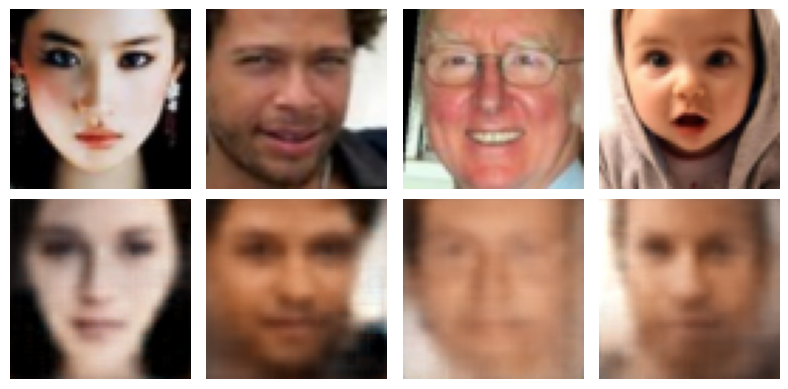

 34%|███▍      | 495/1459 [00:06<00:12, 75.51it/s]

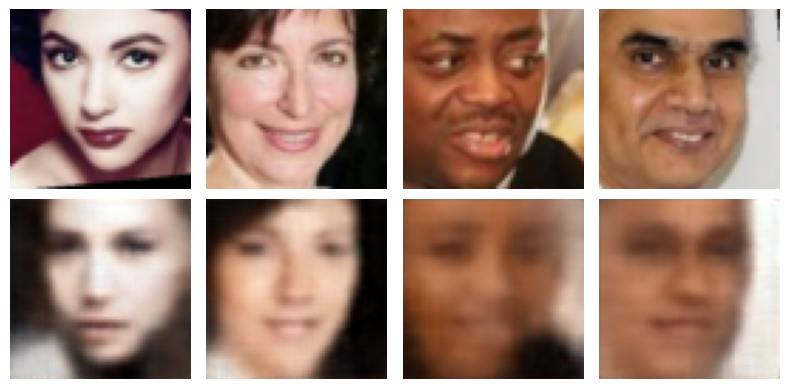

 68%|██████▊   | 998/1459 [00:13<00:05, 77.99it/s]

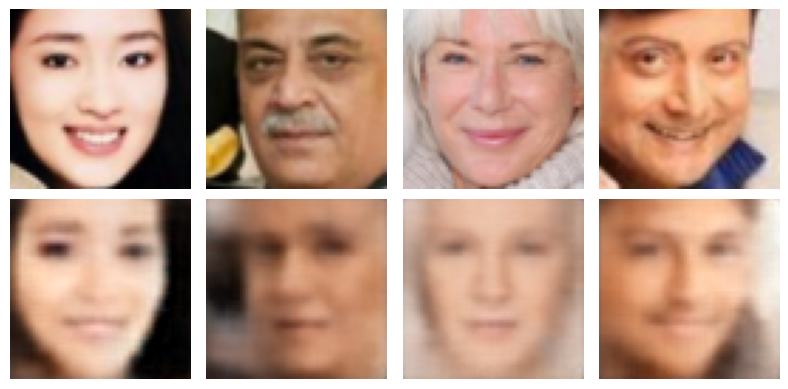

100%|██████████| 1459/1459 [00:19<00:00, 73.20it/s]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : amused_whale_8564
COMET INFO:     url                   : https://www.comet.com/kwadwot/6s191-lab2-part2-dbvae/f8ff993978504a91a0deb77ea20a3793
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [16049] : (0.0397740937769413, 0.9330847263336182)
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 32
COMET INFO:     latent_dim    : 100
COMET INFO:     learning_rate : 0.0005
COMET INFO:     num_epochs    : 10
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     model graph       

In [26]:
### Training the DB-VAE ###

# Hyperparameters
params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=10,  # DB-VAE needs slightly more epochs to train
)

experiment = create_experiment("6S191_Lab2_Part2_DBVAE", params)

# instantiate a new DB-VAE model and optimizer
dbvae = DB_VAE(params["latent_dim"]).to(device)
optimizer = optim.Adam(dbvae.parameters(), lr=params["learning_rate"])


def debiasing_train_step(x, y):
    optimizer.zero_grad()

    y_logit, z_mean, z_logsigma, x_recon = dbvae(x)

    ''''''
    loss, class_loss = debiasing_loss_function(
        x, x_recon, y, y_logit, z_mean, z_logsigma
    )

    loss.backward()
    optimizer.step()

    return loss


# get training faces from data loader
all_faces = loader.get_all_train_faces()

# The training loop -- outer loop iterates over the number of epochs
step = 0
for i in range(params["num_epochs"]):
    IPython.display.clear_output(wait=True)
    print("Starting epoch {}/{}".format(i + 1, params["num_epochs"]))

    # Recompute data sampling proabilities
    """"""
    p_faces = get_training_sample_probabilities(all_faces, dbvae)

    # get a batch of training data and compute the training step
    for j in tqdm(range(loader.get_train_size() // params["batch_size"])):
        # load a batch of data
        (x, y) = loader.get_batch(params["batch_size"], p_pos=p_faces)
        x = torch.from_numpy(x).float().to(device)
        y = torch.from_numpy(y).float().to(device)

        # loss optimization
        loss = debiasing_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()
        experiment.log_metric("loss", loss_value, step=step)

        # plot the progress every 200 steps
        if j % 500 == 0:
            plot_sample(x, y, dbvae, backend="pt")

        step += 1

experiment.end()

Wonderful! Now we should have a trained and (hopefully!) debiased facial classification model, ready for evaluation!

## 2.6 Evaluation of DB-VAE on Test Dataset

Finally let's test our DB-VAE model on the held-out UTKFace test set, looking at its classification rate on each of the **10 race × gender groups** (White / Black / Asian / Indian / Other × Female / Male). We compare the performance of this debiased model against the (potentially biased) standard CNN from earlier in the lab.

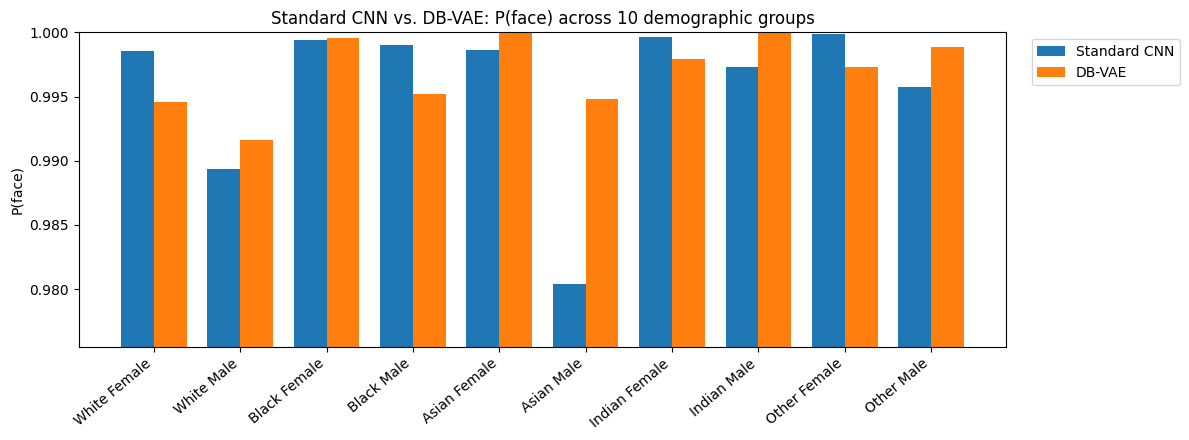

In [27]:
dbvae.to(device)
dbvae_logits_list = []
for face in test_faces:
    face = np.asarray(face, dtype=np.float32)
    face = torch.from_numpy(face).to(device)

    # Forward pass to get the classification logit
    with torch.inference_mode():
        logit = dbvae.predict(face)

    dbvae_logits_list.append(logit.detach().cpu().numpy())

dbvae_logits_array = np.concatenate(dbvae_logits_list, axis=0)
dbvae_logits_tensor = torch.from_numpy(dbvae_logits_array)
dbvae_probs_tensor = torch.sigmoid(dbvae_logits_tensor)
dbvae_probs_array = dbvae_probs_tensor.squeeze(dim=-1).numpy()

xx = np.arange(len(keys))
std_probs_mean = standard_classifier_probs.mean(axis=1)
dbvae_probs_mean = dbvae_probs_array.reshape(len(keys), -1).mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4.5))
width = 0.38
ax.bar(xx - width / 2, std_probs_mean, width=width, label="Standard CNN")
ax.bar(xx + width / 2, dbvae_probs_mean, width=width, label="DB-VAE")
ax.set_xticks(xx)
ax.set_xticklabels(keys, rotation=40, ha="right")
ax.set_ylabel("P(face)")
ax.set_title("Standard CNN vs. DB-VAE: P(face) across 10 demographic groups")
# Zoom y-axis so 1-percentage-point gaps between models/groups are visible.
all_vals = np.concatenate([std_probs_mean, dbvae_probs_mean])
ax.set_ylim(max(0.0, all_vals.min() * 0.995), 1.0)
ax.axhline(1.0, ls="--", lw=0.5, color="gray")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [28]:
### Diagnostic: is the trained DB-VAE actually classifying or is it a "yes" oracle? ###
# DIAGNOSTIC: yes-oracle check
# Evaluate the currently-trained `dbvae` on a balanced batch of faces + non-faces.
# If the model classifies non-faces correctly we'd see P(face) ~ 0 on them; if
# it's degenerated into a yes-oracle (as the loss-function bug in cell 40
# predicts) we'd see P(face) ~ 1 on EVERYTHING. This is read-only -- it does
# not modify the model or the kernel state.

dbvae.eval()
x_mix, y_mix = loader.get_batch(1000)   # 50/50 face/non-face by construction
x_t = torch.from_numpy(x_mix).float().to(device)
with torch.inference_mode():
    probs = torch.sigmoid(dbvae.predict(x_t)).squeeze(-1).cpu().numpy()
y_flat = y_mix.reshape(-1)

face_probs = probs[y_flat == 1]
nonface_probs = probs[y_flat == 0]
print(f"n_faces={len(face_probs)}  n_nonfaces={len(nonface_probs)}")
print(f"P(face) on faces:     mean={face_probs.mean():.4f}  min={face_probs.min():.4f}  max={face_probs.max():.4f}")
print(f"P(face) on non-faces: mean={nonface_probs.mean():.4f}  min={nonface_probs.min():.4f}  max={nonface_probs.max():.4f}")
print(f"Face accuracy     (P>0.5): {(face_probs > 0.5).mean():.4f}")
print(f"Non-face accuracy (P<0.5): {(nonface_probs < 0.5).mean():.4f}")
print()
print("Interpretation:")
print("  - Non-face accuracy ~ 0.0 => yes-oracle confirmed (loss bug)")
print("  - Non-face accuracy ~ 1.0 => model classifies correctly; bug hypothesis wrong")

n_faces=500  n_nonfaces=500
P(face) on faces:     mean=0.9995  min=0.7901  max=1.0000
P(face) on non-faces: mean=0.0002  min=0.0000  max=0.0332
Face accuracy     (P>0.5): 1.0000
Non-face accuracy (P<0.5): 1.0000

Interpretation:
  - Non-face accuracy ~ 0.0 => yes-oracle confirmed (loss bug)
  - Non-face accuracy ~ 1.0 => model classifies correctly; bug hypothesis wrong


In [29]:
### Alpha sweep (Colab-portable, self-contained) ###
# COLAB-SWEEP: self-contained alpha sweep
# 3-SEED: wrapped in seed loop
# Loops over alpha values and seeds. `sweep_results_raw[alpha][seed]` keeps
# the per-(alpha, seed) point estimates; `sweep_results[alpha]` aggregates
# across seeds with mean and SEM. Cell 58 (plot) and cell 59 (JSON) read from
# the aggregated dict. Uses only notebook-local symbols + numpy/torch/tqdm/
# IPython.display -- still Colab-portable.

ALPHA_GRID = [None, 0.1, 0.05, 0.01, 0.001]   # None = no debiasing (uniform sampling)
NUM_EPOCHS = 10
SEEDS = [0, 1, 2]


def train_and_eval(alpha, num_epochs, seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = DB_VAE(latent_dim).to(device)
    opt = optim.Adam(model.parameters(), lr=5e-4)
    all_faces_local = loader.get_all_train_faces()

    for epoch in range(num_epochs):
        IPython.display.clear_output(wait=True)
        print(f"alpha={alpha}  seed={seed}  epoch {epoch + 1}/{num_epochs}")
        if alpha is None:
            p_faces = None  # uniform sampling = "no debiasing" baseline
        else:
            p_faces = get_training_sample_probabilities(
                all_faces_local, model, smoothing_fac=alpha
            )
        for _ in tqdm(range(loader.get_train_size() // 32)):
            x, y = loader.get_batch(32, p_pos=p_faces)
            x = torch.from_numpy(x).float().to(device)
            y = torch.from_numpy(y).float().to(device)
            opt.zero_grad()
            y_logit, z_mean, z_logsigma, x_recon = model(x)
            loss, _ = debiasing_loss_function(
                x, x_recon, y, y_logit, z_mean, z_logsigma
            )
            loss.backward()
            opt.step()

    # Per-group accuracy at threshold 0.5.
    model.eval()
    per_group = {}
    with torch.inference_mode():
        for group, key in zip(test_faces, keys):
            xb = torch.from_numpy(np.asarray(group, dtype=np.float32)).to(device)
            probs = torch.sigmoid(model.predict(xb)).squeeze(-1).cpu().numpy()
            per_group[key] = float((probs > 0.5).mean())
    accs = np.array(list(per_group.values()))
    return per_group, float(accs.mean()), float(accs.var())


# Raw per-(alpha, seed) results.
sweep_results_raw = {a: {} for a in ALPHA_GRID}
for alpha in ALPHA_GRID:
    for seed in SEEDS:
        pg, ea, va = train_and_eval(alpha, NUM_EPOCHS, seed)
        sweep_results_raw[alpha][seed] = {"per_group": pg, "E_A": ea, "Var_A": va}
        print(f"alpha={alpha} seed={seed}: E[A]={ea:.4f}  Var[A]={va:.6e}")


# Aggregate across seeds. sweep_results[alpha] keeps the same schema as the
# 1-seed version (per_group, E_A, Var_A are MEANS) plus *_sem keys.
def _mean_sem(xs):
    import numpy as _np
    arr = _np.asarray(xs, dtype=_np.float64)
    if len(arr) <= 1:
        return float(arr.mean()) if len(arr) else float("nan"), 0.0
    return float(arr.mean()), float(arr.std(ddof=1) / _np.sqrt(len(arr)))


sweep_results = {}
for alpha in ALPHA_GRID:
    per_seed = sweep_results_raw[alpha]
    e_mean, e_sem = _mean_sem([per_seed[s]["E_A"] for s in SEEDS])
    v_mean, v_sem = _mean_sem([per_seed[s]["Var_A"] for s in SEEDS])
    pg_mean, pg_sem = {}, {}
    for key in keys:
        pg_mean[key], pg_sem[key] = _mean_sem(
            [per_seed[s]["per_group"][key] for s in SEEDS]
        )
    sweep_results[alpha] = {
        "per_group": pg_mean,
        "per_group_sem": pg_sem,
        "E_A": e_mean,
        "E_A_sem": e_sem,
        "Var_A": v_mean,
        "Var_A_sem": v_sem,
        "n_seeds": len(SEEDS),
    }
    print(f"alpha={alpha}: E[A]={e_mean:.4f} +/- {e_sem:.4f}  "
          f"Var[A]={v_mean:.4e} +/- {v_sem:.4e}")

alpha=0.001  seed=2  epoch 10/10
Recomputing the sampling probabilities


100%|██████████| 1459/1459 [00:17<00:00, 81.56it/s]


alpha=0.001 seed=2: E[A]=0.9975  Var[A]=1.125000e-05
alpha=None: E[A]=0.9982 +/- 0.0004  Var[A]=8.7500e-06 +/- 2.3761e-06
alpha=0.1: E[A]=0.9980 +/- 0.0003  Var[A]=1.0833e-05 +/- 3.0046e-07
alpha=0.05: E[A]=0.9970 +/- 0.0005  Var[A]=1.2167e-05 +/- 1.5568e-06
alpha=0.01: E[A]=0.9977 +/- 0.0002  Var[A]=9.5000e-06 +/- 1.6266e-06
alpha=0.001: E[A]=0.9975 +/- 0.0003  Var[A]=1.2750e-05 +/- 1.6266e-06


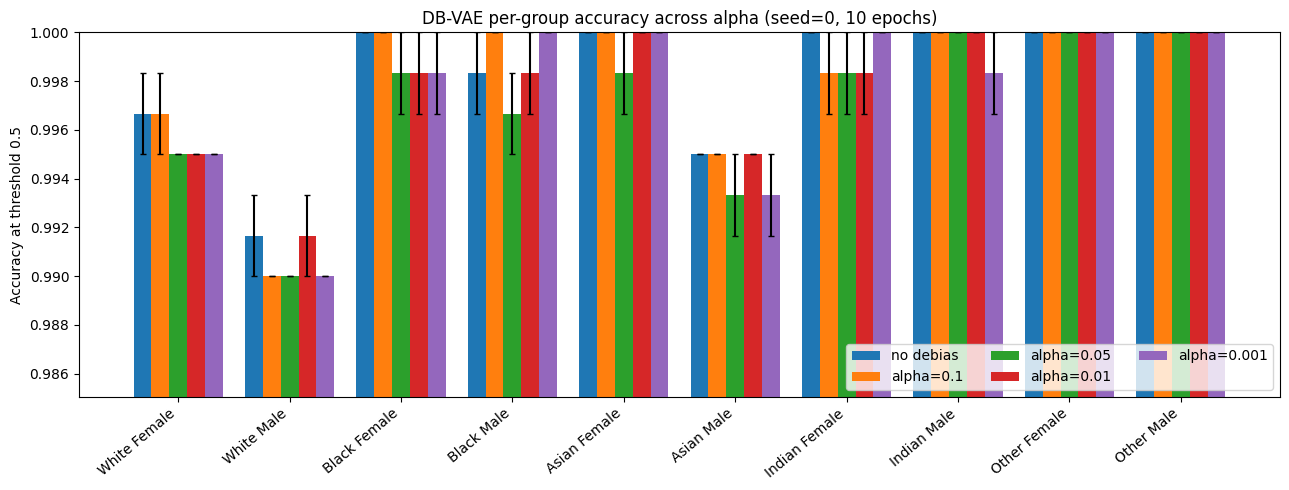

   condition      E[A]        Var[A]
   no_debias  0.9982  8.7500e-06
   alpha=0.1  0.9980  1.0833e-05
  alpha=0.05  0.9970  1.2167e-05
  alpha=0.01  0.9977  9.5000e-06
 alpha=0.001  0.9975  1.2750e-05


In [30]:
### Plot sweep results (zoomed) ###
# COLAB-SWEEP: zoomed per-group accuracy plot
# Plots per-group accuracy bars with the y-axis zoomed to the actual accuracy
# range so 1pp differences are visible, plus a printed summary table.

fig, ax = plt.subplots(figsize=(13, 5))
xx = np.arange(len(keys))
width = 0.16
alphas = list(sweep_results.keys())
offsets = np.linspace(-(len(alphas) - 1) / 2, (len(alphas) - 1) / 2, len(alphas))
for off, a in zip(offsets, alphas):
    label = "no debias" if a is None else f"alpha={a:g}"
    accs = [sweep_results[a]["per_group"][k] for k in keys]
    sems = [sweep_results[a].get("per_group_sem", {}).get(k, 0.0) for k in keys]
    ax.bar(xx + off * width, accs, yerr=sems, capsize=2, width=width, label=label)

# Zoom y-axis to where the signal lives (rather than 0-1).
all_accs = [v for r in sweep_results.values() for v in r["per_group"].values()]
y_lo = min(all_accs) * 0.995
ax.set_ylim(y_lo, 1.0)
ax.axhline(1.0, ls="--", lw=0.5, color="gray")
ax.set_xticks(xx)
ax.set_xticklabels(keys, rotation=40, ha="right")
ax.set_ylabel("Accuracy at threshold 0.5")
ax.set_title(f"DB-VAE per-group accuracy across alpha (seed={SEED}, {NUM_EPOCHS} epochs)")
ax.legend(loc="lower right", ncol=3)
plt.tight_layout()
plt.show()

print(f"{'condition':>12s}  {'E[A]':>8s}  {'Var[A]':>12s}")
for a in alphas:
    label = "no_debias" if a is None else f"alpha={a:g}"
    print(f"{label:>12s}  {sweep_results[a]['E_A']:.4f}  {sweep_results[a]['Var_A']:.4e}")

In [31]:
### Persist sweep_results for the paper figures (optional, local only) ###
# SAVE: persist sweep_results for paper figures
# Writes results/sweep_summary.json in the schema that
# scripts/make_paper_figures.py expects. Safe to skip in Colab (the file
# write will just land in the ephemeral session FS).

import json as _json
from pathlib import Path as _Path

def _serialize_alpha(a):
    return "no_debias" if a is None else f"alpha_{a:g}"

_payload = {}
for _a, _r in sweep_results.items():
    _key = _serialize_alpha(_a)
    _payload[_key] = {
        "alpha": _a,
        "n_seeds": _r.get("n_seeds", 1),
        "E_A_mean": _r["E_A"],
        "E_A_sem": _r.get("E_A_sem", 0.0),
        "Var_A_mean": _r["Var_A"],
        "Var_A_sem": _r.get("Var_A_sem", 0.0),
        "per_group_acc_mean": _r["per_group"],
        "per_group_acc_sem": _r.get("per_group_sem", {_k: 0.0 for _k in _r["per_group"]}),
    }

_Path("results").mkdir(exist_ok=True)
_out = _Path("results") / "sweep_summary.json"
with _out.open("w", encoding="utf-8") as _f:
    _json.dump(_payload, _f, indent=2)
print(f"Wrote {_out}")

Wrote results\sweep_summary.json


## 2.7 Conclusion and submission information

We encourage you to think about and maybe even address some questions raised by the approach and results outlined here:

*  How does the accuracy of the DB-VAE across the 10 race × gender groups compare to that of the standard CNN? Do you find this result surprising in any way? Are there patterns that emerge along race vs. along gender?
*  Can the performance of the DB-VAE classifier be improved even further?
*  In which applications (either related to facial detection or not!) would debiasing in this way be desired? Are there applications where you may not want to debias your model?
* Do you think it should be necessary for companies to demonstrate that their models, particularly in the context of tasks like facial detection, are not biased? If so, do you have thoughts on how this could be standardized and implemented?
* Do you have ideas for other ways to address issues of bias, particularly in terms of the training data?

**The debiased model may or may not perform well based on the initial hyperparameters. This lab competition will be focused on your answers to the questions above, experiments you tried, and your interpretation and analysis of the results. To enter the competition, please upload the following to the lab submission site for the Debiasing Faces Lab ([submission upload link](https://www.dropbox.com/request/SG6AnjrtIljNPrbEOMfP)).**

* Jupyter notebook with the code you used to generate your results;
* copy of the bar plot from section 2.6 showing the performance of your model;
* a written description and/or diagram of the architecture and hyperparameters you used -- if there are any additional or interesting modifications you made to the template code, please include these in your description;
* a written discussion of why and how these modifications changed performance.

**Name your file in the following format: `[FirstName]_[LastName]_Face`, followed by the file format (.zip, .ipynb, .pdf, etc).** ZIP files are preferred over individual files. If you submit individual files, you must name the individual files according to the above nomenclature (e.g., `[FirstName]_[LastName]_Face_TODO.pdf`, `[FirstName]_[LastName]_Face_Report.pdf`, etc.).

Hopefully this lab has shed some light on a few concepts, from vision based tasks, to VAEs, to algorithmic bias. We like to think it has, but we're biased ;).

<img src="https://i.ibb.co/BjLSRMM/ezgif-2-253dfd3f9097.gif" />